In [1]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import models, datasets, transforms
import os, glob, cv2
from copy import deepcopy
from mpl_toolkits.mplot3d import Axes3D
from sklearn import cluster
!pip install torchsummary
from torchsummary import summary


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
!git clone https://github.com/udacity/P1_Facial_Keypoints.git

Cloning into 'P1_Facial_Keypoints'...
remote: Enumerating objects: 6049, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6049 (delta 2), reused 1 (delta 1), pack-reused 6044 (from 2)
Receiving objects: 100% (6049/6049), 329.53 MiB | 50.96 MiB/s, done.
Resolving deltas: 100% (156/156), done.


In [4]:
!cd P1_Facial_Keypoints

In [5]:
root_dir = "/content/P1_Facial_Keypoints/data/training"
all_images_path = glob.glob(os.path.join(root_dir, "*.jpg"))
data = pd.read_csv("/content/P1_Facial_Keypoints/data/training_frames_keypoints.csv")

In [6]:
data.head(2)

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,126,127,128,129,130,131,132,133,134,135
0,Luis_Fonsi_21.jpg,45.0,98.0,47.0,106.0,49.0,110.0,53.0,119.0,56.0,...,83.0,119.0,90.0,117.0,83.0,119.0,81.0,122.0,77.0,122.0
1,Lincoln_Chafee_52.jpg,41.0,83.0,43.0,91.0,45.0,100.0,47.0,108.0,51.0,...,85.0,122.0,94.0,120.0,85.0,122.0,83.0,122.0,79.0,122.0


In [7]:
class FacesData(Dataset):
  def __init__(self, df):
    super(FacesData).__init__()
    self.df = df
    self.normalize = transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )

  def __len__(self):
    return len(self.df)

  def __getitem__(self, ix):
    img_path = "/content/P1_Facial_Keypoints/data/training/" + self.df.iloc[ix, 0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Corrected line: cvtCOLOR to cvtColor
    img = img / 255.0
    # kp values
    kp = deepcopy(self.df.iloc[ix,1:].tolist())
    kp_x = (np.array(kp[0::2])/img.shape[1]).tolist()
    kp_y = (np.array(kp[1::2])/img.shape[0]).tolist() # Corrected y-coordinate calculation
    kp2 = kp_x + kp_y
    kp2 = torch.tensor(kp2).float()
    img = self.preprocess_input(img.astype(np.float32))
    return img , kp2

  def preprocess_input(self, img):
    img = cv2.resize(img, (224, 224))
    img = torch.tensor(img).permute(2, 0, 1)
    img = self.normalize(img).float()
    return img.to(device)

  def load_img(self, ix):
    img_path = "/content/P1_Facial_Keypoints/data/training/" + self.df.iloc[ix, 0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)/255.0 # Corrected line: cvtCOLOR to cvtColor
    img = cv2.resize(img, (224, 224))
    return img

In [8]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.2, random_state=122)
train_data = FacesData(train.reset_index(drop=True))
test_data = FacesData(test.reset_index(drop=True))
train_loader = DataLoader(train_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [9]:
def get_model():
  model = models.vgg16(pretrained=True)
  for param in model.parameters():
    param.requires_grad = False

  model.avgpool = nn.Sequential(nn.Conv2d(512, 512, 3),
                                nn.MaxPool2d(2),
                                nn.Flatten())
  model.classifier = nn.Sequential(nn.Linear(2048, 512),
                                   nn.ReLU(),
                                   nn.Dropout(0.5),
                                   nn.Linear(512, 136),
                                   nn.Sigmoid()
                                   )
  criterion = nn.L1Loss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.0004)
  return model.to(device), criterion, optimizer

In [10]:
model, criterion, optimizer = get_model()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 77.9MB/s]


In [11]:
def train_batch(img, kps, model, criterion, optimizer):
  model.train()
  optimizer.zero_grad()
  _kps = model(img.to(device))
  loss = criterion(_kps, kps.to(device))
  loss.backward()
  optimizer.step()
  return loss

In [12]:
def validate_batch(img, kps, model, criterion):
  model.eval()
  _kps = model(img.to(device))
  loss = criterion(_kps, kps.to(device))
  return kps, loss

In [13]:
train_loss, test_loss = [], []
epochs = 50

In [15]:
for epoch in range(epochs):
    print(f" epoch {epoch + 1} : 50")
    epoch_train_loss, epoch_test_loss = 0, 0

    for ix, (img, kps) in enumerate(train_loader):
        loss = train_batch(img, kps, model, criterion, optimizer)
        epoch_train_loss += loss.item()
    epoch_train_loss /= (ix + 1)

    for ix, (img, kps) in enumerate(test_loader):
        ps, loss = validate_batch(img, kps, model, criterion)
        epoch_test_loss += loss.item()
    epoch_test_loss /= (ix + 1)

    train_loss.append(epoch_train_loss)
    test_loss.append(epoch_test_loss)

 epoch 1 : 50


 epoch 2 : 50
 epoch 3 : 50
 epoch 4 : 50
 epoch 5 : 50
 epoch 6 : 50
 epoch 7 : 50
 epoch 8 : 50
 epoch 9 : 50
 epoch 10 : 50
 epoch 11 : 50
 epoch 12 : 50
 epoch 13 : 50
 epoch 14 : 50
 epoch 15 : 50
 epoch 16 : 50
 epoch 17 : 50
 epoch 18 : 50
 epoch 19 : 50
 epoch 20 : 50
 epoch 21 : 50
 epoch 22 : 50
 epoch 23 : 50
 epoch 24 : 50
 epoch 25 : 50
 epoch 26 : 50
 epoch 27 : 50
 epoch 28 : 50
 epoch 29 : 50
 epoch 30 : 50
 epoch 31 : 50
 epoch 32 : 50
 epoch 33 : 50
 epoch 34 : 50
 epoch 35 : 50
 epoch 36 : 50
 epoch 37 : 50
 epoch 38 : 50
 epoch 39 : 50
 epoch 40 : 50
 epoch 41 : 50
 epoch 42 : 50
 epoch 43 : 50
 epoch 44 : 50
 epoch 45 : 50
 epoch 46 : 50
 epoch 47 : 50
 epoch 48 : 50
 epoch 49 : 50
 epoch 50 : 50


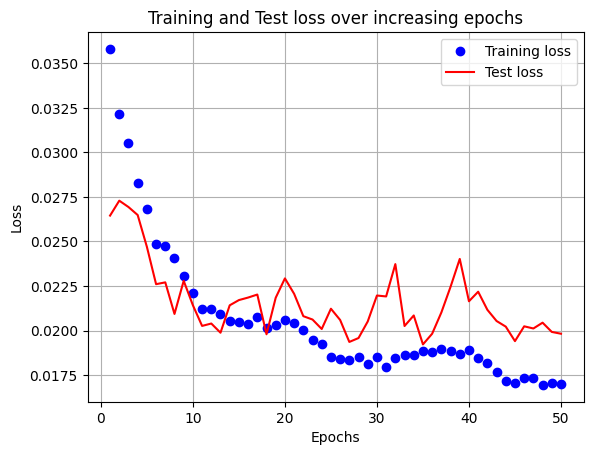

In [17]:
epochs = np.arange(50)+1
import matplotlib.ticker as mtick
import matplotlib.ticker as mticker
plt.plot(epochs, train_loss, 'bo', label='Training loss')
plt.plot(epochs, test_loss, 'r', label='Test loss')
plt.title('Training and Test loss over increasing epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()

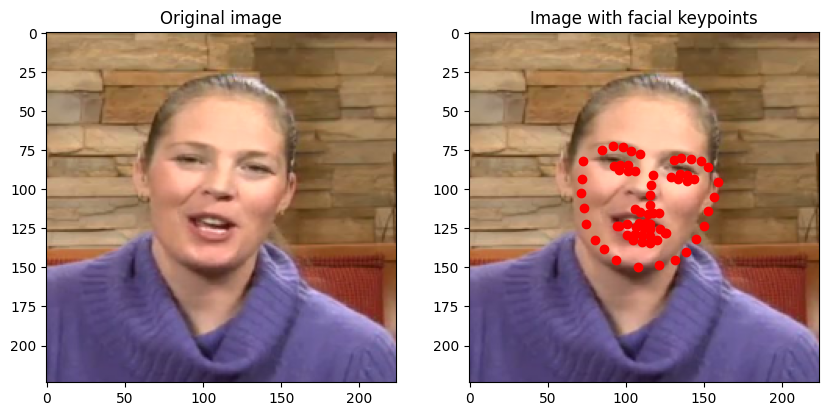

In [33]:
ix = 134
plt.figure(figsize=(10,10))
plt.subplot(221)
plt.title('Original image')
im = test_data.load_img(ix)
plt.imshow(im)
plt.grid(False)
plt.subplot(222)
plt.title('Image with facial keypoints')
x, _ = test_data[ix]
plt.imshow(im)
kp = model(x[None]).flatten().detach().cpu()
plt.scatter(kp[:68]*224, kp[68:]*224, c='r')
plt.grid(False)
plt.show()